In [44]:
# Importing required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import os
import time

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import average_precision_score, roc_auc_score
#from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import optuna

In [29]:
# Load the dataset
df = pd.read_csv("C:/Users/chris/Documents/Projects/Data/creditcard.csv")

# Initial review of the dataset
print(f"Dataset shape: {df.shape}\n")

print("Data Schema:")
df.info()


print("Preview of the dataset:")
df.head(10)

Dataset shape: (284807, 31)

Data Schema:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 no

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [30]:
#Examine the dataset for duplicate records
duplicate_count = df.duplicated().sum()
print (f"Number of duplicate records: {duplicate_count}\n")

#Remove duplicate records if any  
df.drop_duplicates(inplace=True)
print(f"Dataset shape after removing duplicates: {df.shape}\n")

#Examine the dataset for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")    
for col, count in missing_values.items():
    print(f"  {col}: {count}")
print()

#Review class distribution
class_counts = df['Class'].value_counts()
class_percentages = df['Class'].value_counts(normalize=True) * 100


print("--- Class Distribution ---")
for idx, val in class_counts.items():
    label = "Fraud (1)" if idx == 1 else "Normal (0)"
    print(f"{label}: {val} transactions ({class_percentages[idx]:.3f}%)")

Number of duplicate records: 1081

Dataset shape after removing duplicates: (283726, 31)

Missing values in each column:
  Time: 0
  V1: 0
  V2: 0
  V3: 0
  V4: 0
  V5: 0
  V6: 0
  V7: 0
  V8: 0
  V9: 0
  V10: 0
  V11: 0
  V12: 0
  V13: 0
  V14: 0
  V15: 0
  V16: 0
  V17: 0
  V18: 0
  V19: 0
  V20: 0
  V21: 0
  V22: 0
  V23: 0
  V24: 0
  V25: 0
  V26: 0
  V27: 0
  V28: 0
  Amount: 0
  Class: 0

--- Class Distribution ---
Normal (0): 283253 transactions (99.833%)
Fraud (1): 473 transactions (0.167%)


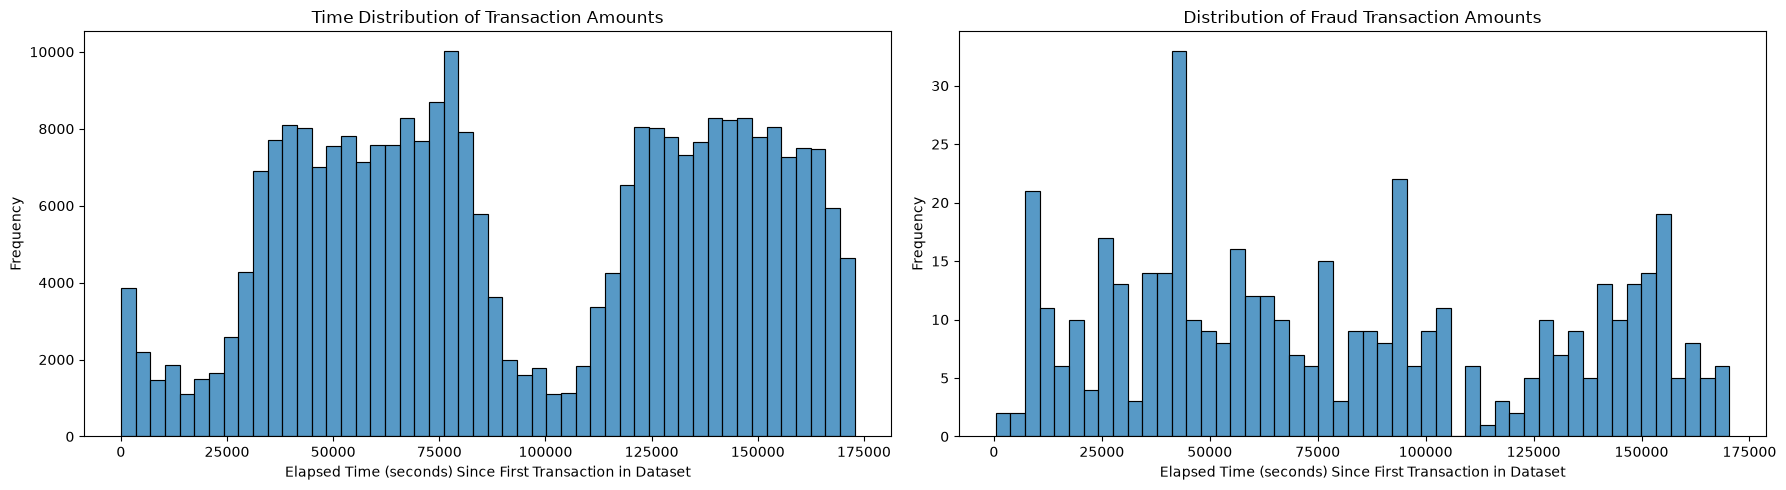

In [31]:
# Visualize time feature distribution for all transactions and fraud transactions only
fig_time, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(data=df['Time'], bins=50, ax=axes[0])
axes[0].set_title('Time Distribution of Transaction Amounts')
axes[0].set_xlabel('Elapsed Time (seconds) Since First Transaction in Dataset')
axes[0].set_ylabel('Frequency')

sns.histplot(data=df[df['Class'] == 1]['Time'], bins=50, ax=axes[1])
axes[1].set_title('Distribution of Fraud Transaction Amounts')
axes[1].set_xlabel('Elapsed Time (seconds) Since First Transaction in Dataset')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#sns.histplot(x='Amount', data=df, ax=axes[2])

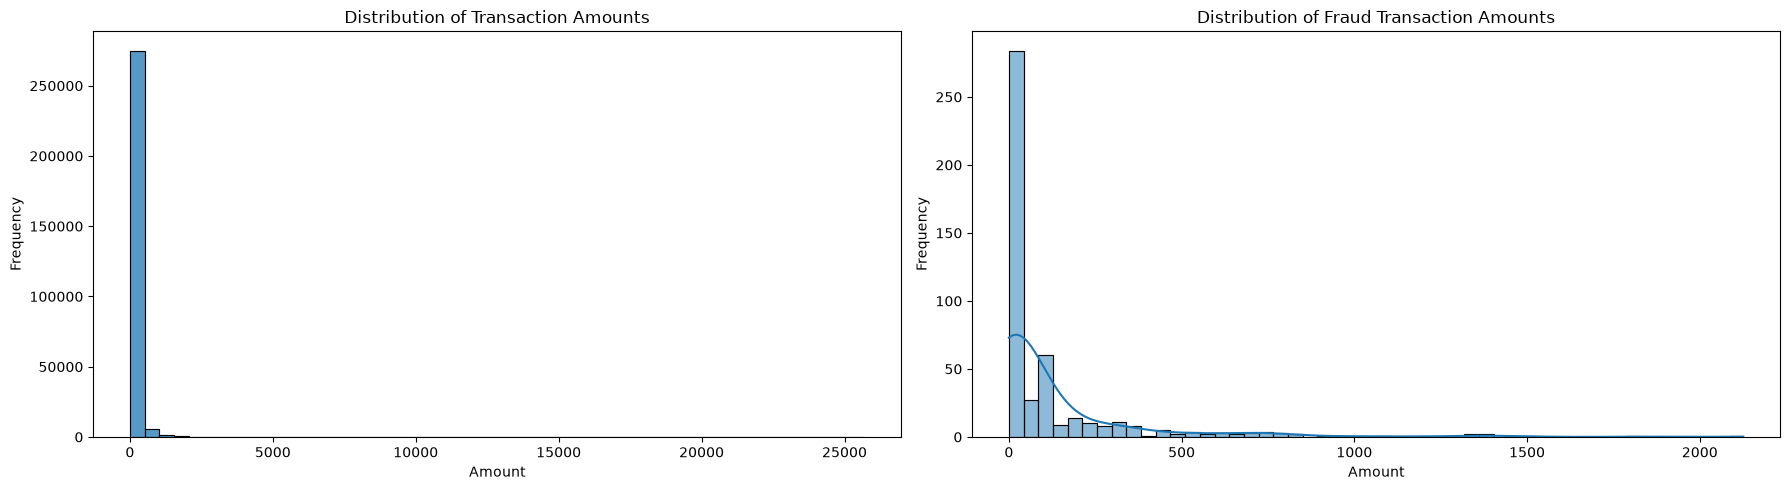

In [32]:
#Visualize amount feature distribution for all transactions and fraud transactions only
fig_amount, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(data=df['Amount'], bins=50, ax=axes[0])
axes[0].set_title('Distribution of Transaction Amounts')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')
#axes[0].set_ylim(bottom=0, top=25000)  # Set y-axis to logarithmic scale for better visibility of distribution

sns.histplot(data=df[df['Class'] == 1]['Amount'], bins=50, ax=axes[1], kde=True)
axes[1].set_title('Distribution of Fraud Transaction Amounts')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [33]:
#Preparing the data for modeling
# Scaling 'Time' and 'Amount' features
# RobustScaler is used instead of StandardScaler; less sensitive to extreme outliers
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop original unscaled columns
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Insert scaled columns at the beginning of the DataFrame for consistency
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']


In [34]:
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

In [35]:
df

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.774718,-0.995290,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.268530,-0.995290,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.959811,-0.995279,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.411487,-0.995279,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.667362,-0.995267,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-0.295230,1.035258,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,...,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0
284803,0.038798,1.035270,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,...,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,0
284804,0.638020,1.035282,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,...,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,0
284805,-0.166875,1.035282,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,...,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,0


In [36]:
# Splitting the dataset into features and target variable
X = df.drop('Class', axis=1)
y = df['Class']     

# Splitting into test and train sets - stratified to maintain class distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n--- Train and Test Set Dimensions ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

print("\n--- Fraud Ratio in Subsets ---")
print(f"Train Fraud Ratio: {y_train.value_counts(normalize=True)[1]*100:.3f}%")
print(f"Test Fraud Ratio:  {y_test.value_counts(normalize=True)[1]*100:.3f}%")


--- Train and Test Set Dimensions ---
X_train shape: (226980, 30)
X_test shape: (56746, 30)

--- Fraud Ratio in Subsets ---
Train Fraud Ratio: 0.167%
Test Fraud Ratio:  0.167%


In [38]:
#Initialize model - Random Forest

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

#predict
y_pred = rf.predict(X_test)

print(f"--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred))
print("-" * 50 + "\n")

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.79      0.76      0.77        95

    accuracy                           1.00     56746
   macro avg       0.90      0.88      0.89     56746
weighted avg       1.00      1.00      1.00     56746

--------------------------------------------------



In [46]:
# XGBoost Classifier - Baseline model with default hyperparameters
# Calculate the ratio for scale_pos_weight (Negative Class Count / Positive Class Count)
# This acts like class_weight='balanced' for XGBoost and LightGBM
neg_class_count = (y_train == 0).sum()
pos_class_count = (y_train == 1).sum()
scale_weight = neg_class_count / pos_class_count

xgb_baseline = xgb.XGBClassifier(
        objective='binary:logistic',
    learning_rate=0.1,     
    max_depth=6,            
    n_estimators=100,      
    subsample=0.8,          
    colsample_bytree=0.8,   
    reg_alpha=0.1,       
    reg_lambda=1,         
    gamma=0,              
    booster='gbtree',    
    tree_method='auto',    
    scale_pos_weight=scale_weight,
    random_state=42) 

xgb_baseline.fit(X_train, y_train)

y_pred = xgb_baseline.predict(X_test)

print(f"--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred))
print("-" * 50 + "\n")

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.83      0.81      0.82        95

    accuracy                           1.00     56746
   macro avg       0.91      0.91      0.91     56746
weighted avg       1.00      1.00      1.00     56746

--------------------------------------------------



In [40]:
# LGB Classifier - Baseline model with default hyperparameters

lgb = lgb.LGBMClassifier(
    objective='binary',
    learning_rate=0.1,
    max_depth=-1,
    n_estimators=100,
    scale_pos_weight=scale_weight,
    random_state=42)

lgb.fit(X_train, y_train)

y_pred = lgb.predict(X_test)

print(f"--- LightGBM Classification Report ---")
print(classification_report(y_test, y_pred))
print("-" * 50 + "\n")

[LightGBM] [Info] Number of positive: 378, number of negative: 226602
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016945 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 226980, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001665 -> initscore=-6.396056
[LightGBM] [Info] Start training from score -6.396056
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [41]:
# Shared evaluation helper and CV splitter for the tuning experiments below.
# PR-AUC (average precision) is the headline metric throughout: at a 0.17% positive rate
# accuracy is meaningless (99.8% by predicting "not fraud" every time) and ROC-AUC is
# optimistically biased because the enormous negative class keeps the false positive rate
# tiny no matter how many false alarms are raised.

def evaluate(name, model, X_te, y_te, threshold=0.5):
    """Score a fitted model on the test set at a given decision threshold."""
    y_proba = model.predict_proba(X_te)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()

    print(f"--- {name} (threshold = {threshold:.4f}) ---")
    print(classification_report(y_te, y_pred, digits=4, target_names=['Normal', 'Fraud']))
    print(f"PR-AUC (average precision): {average_precision_score(y_te, y_proba):.4f}")
    print(f"ROC-AUC:                    {roc_auc_score(y_te, y_proba):.4f}")
    print(f"Frauds caught:  {tp} of {tp + fn}")
    print(f"False alarms:   {fp} legitimate transactions flagged")
    print("-" * 50 + "\n")

    return {'name': name, 'threshold': threshold,
            'pr_auc': average_precision_score(y_te, y_proba),
            'roc_auc': roc_auc_score(y_te, y_proba),
            'precision': tp / (tp + fp) if (tp + fp) else 0.0,
            'recall': tp / (tp + fn),
            'tp': tp, 'fp': fp, 'fn': fn}


# One splitter reused by every search below so the results are directly comparable.
# Stratifying matters here - with only ~380 frauds in the training set, unstratified folds
# could land with very different fraud rates and produce needlessly noisy scores.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

results = {}

In [47]:
# Tuning XGBoost Classifier with hyperparameter optimization using GridSearchCV
#
# Grid search fits EVERY combination in the grid. That makes it exhaustive, perfectly
# reproducible and trivially parallel, but the cost is the product of the list lengths -
# adding one more three-value parameter triples the runtime. The grid below is deliberately
# small and centred on the baseline values from the cell above; the remaining knobs are
# pinned so the search stays tractable, and Optuna explores them properly later.

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.3],
    'n_estimators': [100, 300],
    'subsample': [0.8, 1.0],
}
FIXED = {'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1, 'gamma': 0}

n_combos = int(np.prod([len(v) for v in param_grid.values()]))
print(f"Grid size: {n_combos} combinations x {cv.get_n_splits()} folds = "
      f"{n_combos * cv.get_n_splits()} model fits\n")

xgb_grid_base = xgb.XGBClassifier(
    objective='binary:logistic',
    booster='gbtree',
    tree_method='hist',              # histogram splitting - far faster than exact on 227k rows
    scale_pos_weight=scale_weight,   # reuses the imbalance ratio from the baseline cell
    random_state=42,
    n_jobs=-1,
    **FIXED)

grid_search = GridSearchCV(
    estimator=xgb_grid_base,
    param_grid=param_grid,
    scoring='average_precision',     # PR-AUC - optimising accuracy here would be useless
    cv=cv,
    n_jobs=1,                        # XGBoost already uses every core; setting n_jobs=-1 in
                                     # both places oversubscribes the CPU and runs slower
    verbose=1,
    refit=True)                      # refit the winner on the full training set

start = time.time()
grid_search.fit(X_train, y_train)
grid_elapsed = time.time() - start

print(f"\nGrid search took {grid_elapsed:.1f}s "
      f"({grid_elapsed / (n_combos * cv.get_n_splits()):.1f}s per fit)")
print(f"Best CV PR-AUC: {grid_search.best_score_:.4f}")
print("Best parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print()

# The full CV table is worth a look: it usually shows a broad plateau of near-identical
# scores, which is exactly why exhaustively sweeping a lattice is such a poor use of time.
cv_results = (pd.DataFrame(grid_search.cv_results_)
                [['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
                .sort_values('rank_test_score'))
print("Top 5 configurations:")
print(cv_results.head(5).to_string(index=False))
print(f"\nScore spread across the whole grid: "
      f"{cv_results['mean_test_score'].min():.4f} - {cv_results['mean_test_score'].max():.4f}")
print("-" * 50 + "\n")

xgb_grid = grid_search.best_estimator_
results['grid'] = evaluate("XGBoost - GridSearchCV", xgb_grid, X_test, y_test)

Grid size: 36 combinations x 3 folds = 108 model fits

Fitting 3 folds for each of 36 candidates, totalling 108 fits

Grid search took 510.6s (4.7s per fit)
Best CV PR-AUC: 0.8508
Best parameters:
  learning_rate: 0.3
  max_depth: 5
  n_estimators: 100
  subsample: 0.8

Top 5 configurations:
                                                                        params  mean_test_score  std_test_score  rank_test_score
 {'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}         0.850783        0.022148                1
 {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}         0.850450        0.021654                2
{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}         0.850417        0.021886                3
{'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}         0.850342        0.021525                4
 {'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 300, '

Out-of-fold probabilities computed in 9.0s (3 fits)

Default threshold:           0.5000
Best-F1 threshold:           0.7084  (out-of-fold F1 = 0.8648)
Recall >= 90% threshold:     0.0002  (out-of-fold precision = 0.0566)
Alert budget 0.1% threshold:  0.9999



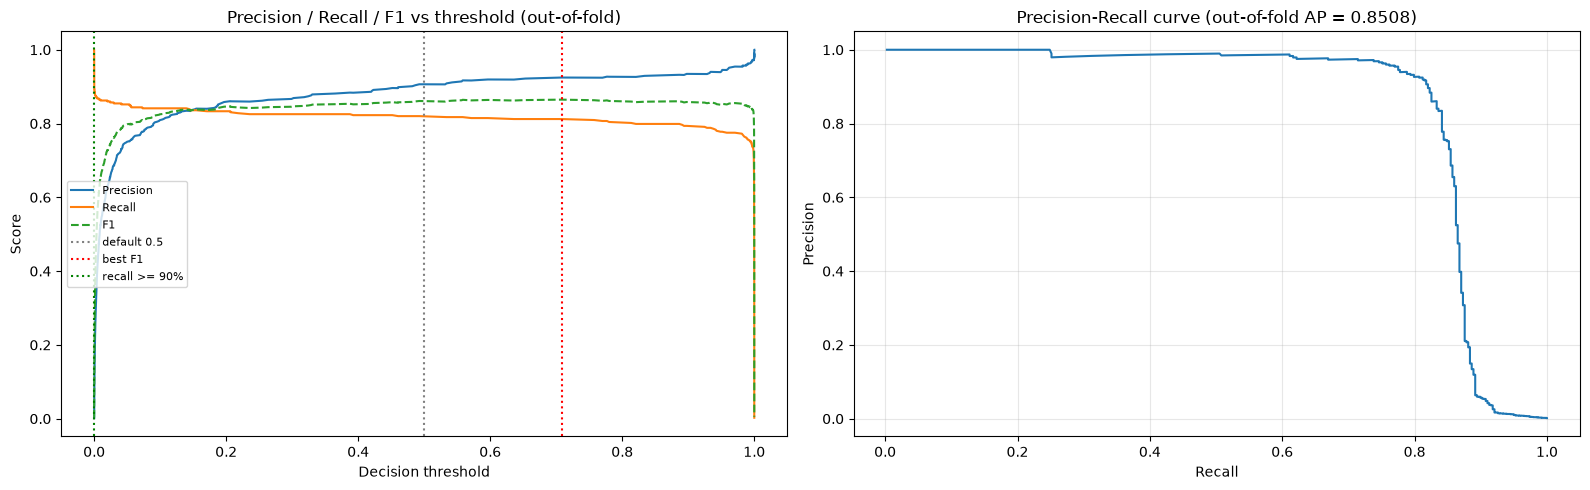

--- XGBoost - default threshold (threshold = 0.5000) ---
              precision    recall  f1-score   support

      Normal     0.9996    0.9999    0.9998     56651
       Fraud     0.9359    0.7684    0.8439        95

    accuracy                         0.9995     56746
   macro avg     0.9678    0.8842    0.9218     56746
weighted avg     0.9995    0.9995    0.9995     56746

PR-AUC (average precision): 0.8224
ROC-AUC:                    0.9736
Frauds caught:  73 of 95
False alarms:   5 legitimate transactions flagged
--------------------------------------------------

--- XGBoost - best-F1 threshold (threshold = 0.7084) ---
              precision    recall  f1-score   support

      Normal     0.9996    1.0000    0.9998     56651
       Fraud     0.9733    0.7684    0.8588        95

    accuracy                         0.9996     56746
   macro avg     0.9865    0.8842    0.9293     56746
weighted avg     0.9996    0.9996    0.9996     56746

PR-AUC (average precision): 0.8224


In [ ]:
#Tuning XGboost Classifier with thresholding
#
# The decision threshold is not a model hyperparameter - it is the cut-off applied to the
# predicted probabilities AFTER training. Tuning it therefore costs a single model fit
# rather than hundreds, and on a 0.17% positive class the default 0.5 is almost never the
# operating point you actually want.
#
# IMPORTANT: the threshold has to be chosen on data the model did not train on, and it must
# not be the test set - sweeping thresholds on X_test and reporting the best one leaks the
# test set into the model and inflates the result. cross_val_predict gives an out-of-fold
# probability for every training row, so the whole training set can be used honestly.

# Here we use the best model from the grid search above, but any fitted model would do.
xgb_threshold = xgb.XGBClassifier(
    objective='binary:logistic',
    learning_rate=0.3,
    max_depth=5,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    gamma=0,
    booster='gbtree',
    tree_method='hist',
    scale_pos_weight=scale_weight,
    random_state=42,
    n_jobs=-1)

start = time.time()
oof_proba = cross_val_predict(xgb_threshold, X_train, y_train, cv=cv,
                              method='predict_proba', n_jobs=1)[:, 1]
print(f"Out-of-fold probabilities computed in {time.time() - start:.1f}s "
      f"({cv.get_n_splits()} fits)\n")

precision, recall, thresholds = precision_recall_curve(y_train, oof_proba)
# precision_recall_curve returns one more precision/recall point than thresholds - the
# trailing (precision=1, recall=0) point has no threshold - so trim the last element
precision, recall = precision[:-1], recall[:-1]

# Strategy 1: maximise F1. The balanced default, appropriate when a missed fraud and a
# false alarm are treated as roughly equally costly.
f1_scores = 2 * precision * recall / (precision + recall + 1e-12)
t_f1 = thresholds[np.argmax(f1_scores)]

# Strategy 2: fix recall, maximise precision. Much closer to how fraud teams actually
# operate ("we must catch 90% of fraud; minimise how many good customers we annoy").
# Take the HIGHEST threshold that still clears the recall floor.
TARGET_RECALL = 0.90
meets_recall = np.where(recall >= TARGET_RECALL)[0]
t_recall = thresholds[meets_recall[-1]]

# Strategy 3: cap the alert volume. When a review team can only work N cases a day, the
# threshold is set by capacity rather than by any statistical criterion.
ALERT_BUDGET = 0.001   # flag at most 0.1% of transactions
t_budget = np.quantile(oof_proba, 1 - ALERT_BUDGET)

print(f"Default threshold:           0.5000")
print(f"Best-F1 threshold:           {t_f1:.4f}  (out-of-fold F1 = {f1_scores.max():.4f})")
print(f"Recall >= {TARGET_RECALL:.0%} threshold:     {t_recall:.4f}  "
      f"(out-of-fold precision = {precision[meets_recall[-1]]:.4f})")
print(f"Alert budget {ALERT_BUDGET:.1%} threshold:  {t_budget:.4f}\n")

# Visualise the trade-off the threshold controls
fig_thresh, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(thresholds, precision, label='Precision')
axes[0].plot(thresholds, recall, label='Recall')
axes[0].plot(thresholds, f1_scores, label='F1', linestyle='--')
for t, lbl, c in [(0.5, 'default 0.5', 'grey'), (t_f1, 'best F1', 'red'),
                  (t_recall, f'recall >= {TARGET_RECALL:.0%}', 'green')]:
    axes[0].axvline(t, color=c, linestyle=':', label=lbl)
axes[0].set_xlabel('Decision threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 vs threshold (out-of-fold)')
axes[0].legend(loc='center left', fontsize=8)

axes[1].plot(recall, precision)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curve (out-of-fold AP = '
                  f'{average_precision_score(y_train, oof_proba):.4f})')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Fit once on the full training set, then read off test performance at each threshold.
# The predicted probabilities are identical in all four rows below - only the cut-off moves,
# which is why PR-AUC does not change while precision and recall swing widely.
xgb_threshold.fit(X_train, y_train)

results['default'] = evaluate("XGBoost - default threshold", xgb_threshold, X_test, y_test, 0.5)
results['thresh_f1'] = evaluate("XGBoost - best-F1 threshold", xgb_threshold, X_test, y_test, t_f1)
results['thresh_recall'] = evaluate(f"XGBoost - recall >= {TARGET_RECALL:.0%}", xgb_threshold, X_test, y_test, t_recall)
results['thresh_budget'] = evaluate(f"XGBoost - {ALERT_BUDGET:.1%} alert budget",
                                    xgb_threshold, X_test, y_test, t_budget)

  0%|          | 0/40 [00:00<?, ?it/s]


Optuna took 1300.2s over 40 trials (11 pruned early)
Best CV PR-AUC: 0.8551
Best parameters:
  max_depth: 5
  learning_rate: 0.044887259849597606
  n_estimators: 500
  subsample: 0.8316475625153044
  colsample_bytree: 0.7670362528229749
  min_child_weight: 3
  gamma: 0.0031197927919285064
  reg_alpha: 1.4166341382224887
  reg_lambda: 8.645176030307823
  scale_pos_weight: 36.645741943675006

Hyperparameter importance:
  min_child_weight     0.293
  learning_rate        0.246
  n_estimators         0.179
  reg_lambda           0.081
  colsample_bytree     0.080
  subsample            0.051
  scale_pos_weight     0.046
  gamma                0.016
  reg_alpha            0.005
  max_depth            0.003
--------------------------------------------------



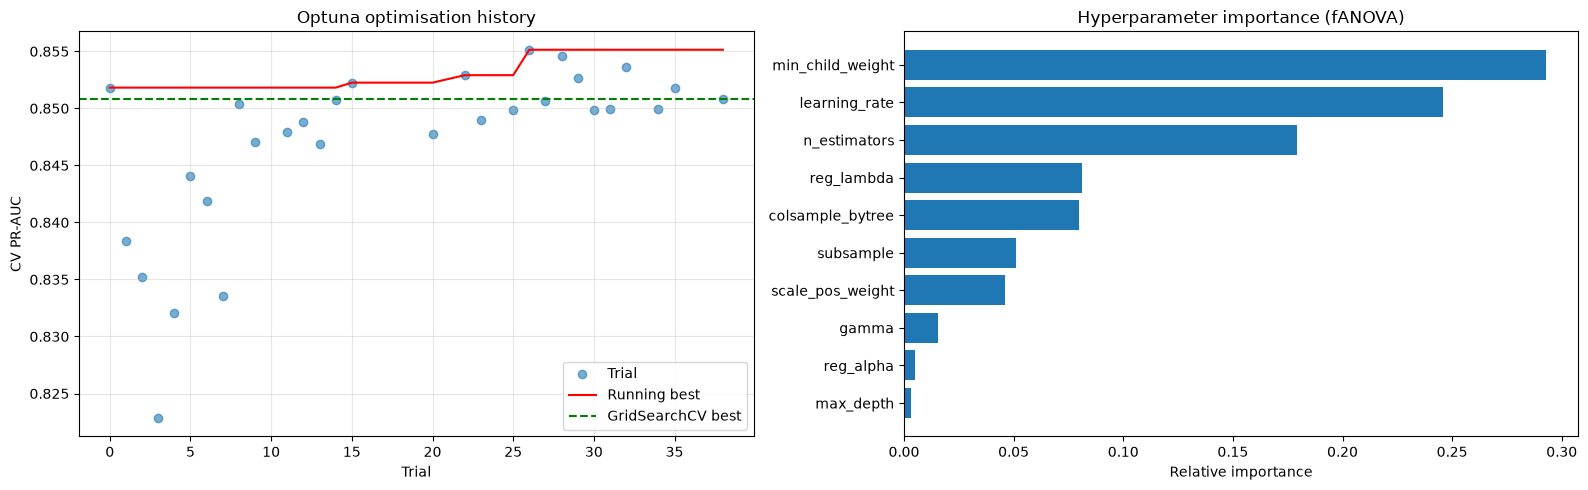

--- XGBoost - Optuna (Bayesian) (threshold = 0.5000) ---
              precision    recall  f1-score   support

      Normal     0.9996    0.9999    0.9998     56651
       Fraud     0.9259    0.7895    0.8523        95

    accuracy                         0.9995     56746
   macro avg     0.9628    0.8947    0.9260     56746
weighted avg     0.9995    0.9995    0.9995     56746

PR-AUC (average precision): 0.8250
ROC-AUC:                    0.9799
Frauds caught:  75 of 95
False alarms:   6 legitimate transactions flagged
--------------------------------------------------



In [49]:
#Tuning XGBoost Classifier with Bayesian Optimization using Optuna
#
# Bayesian optimisation builds a probabilistic model of (hyperparameters -> score) from the
# trials run so far and uses it to choose each next trial, concentrating the budget on
# promising regions instead of sweeping a fixed lattice. Two practical consequences:
#   - parameters are drawn from continuous ranges, so the search is not restricted to the
#     handful of values you happened to type into a grid
#   - the budget is set by n_trials, independently of how many parameters are being tuned,
#     so adding a tenth parameter costs no extra runtime (it just needs more trials to
#     explore the larger space well)
# Pruning abandons unpromising trials part-way through cross-validation, and that is where
# most of the saving over grid search actually comes from.

def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'booster': 'gbtree',
        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1,
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 600, step=50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        # scale_pos_weight is treated as tunable rather than pinned at the class ratio. The
        # full ratio (~577) is the right choice for balanced accuracy, but it tends to
        # over-predict fraud when the objective is PR-AUC - let the search decide.
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, scale_weight, log=True),
    }

    # A manual fold loop rather than cross_val_score, so an intermediate score can be
    # reported to the pruner after each fold and hopeless trials abandoned early.
    fold_scores = []
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train)):
        model = xgb.XGBClassifier(**params)
        model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        va_proba = model.predict_proba(X_train.iloc[va_idx])[:, 1]
        fold_scores.append(average_precision_score(y_train.iloc[va_idx], va_proba))

        trial.report(float(np.mean(fold_scores)), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_scores))


N_TRIALS = 40   # the single cost knob - unlike a grid, it is independent of how many
                # parameters are being tuned

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),   # seeded so the notebook reruns identically
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=1),
    study_name='xgb_fraud_prauc')

start = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
optuna_elapsed = time.time() - start

n_pruned = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
print(f"\nOptuna took {optuna_elapsed:.1f}s over {N_TRIALS} trials ({n_pruned} pruned early)")
print(f"Best CV PR-AUC: {study.best_value:.4f}")
print("Best parameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print()

# Which parameters actually mattered? Grid search cannot answer this.
importances = optuna.importance.get_param_importances(study)
print("Hyperparameter importance:")
for k, v in importances.items():
    print(f"  {k:20s} {v:.3f}")
print("-" * 50 + "\n")

# Optimisation history: the running best should climb quickly then flatten, and the scatter
# should visibly tighten around the good region as TPE learns where to look.
fig_optuna, axes = plt.subplots(1, 2, figsize=(16, 5))

completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
trial_nums = [t.number for t in completed]
trial_vals = [t.value for t in completed]

axes[0].scatter(trial_nums, trial_vals, alpha=0.6, label='Trial')
axes[0].plot(trial_nums, np.maximum.accumulate(trial_vals), color='red', label='Running best')
axes[0].axhline(grid_search.best_score_, color='green', linestyle='--', label='GridSearchCV best')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('CV PR-AUC')
axes[0].set_title('Optuna optimisation history')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].barh(list(importances.keys())[::-1], list(importances.values())[::-1])
axes[1].set_xlabel('Relative importance')
axes[1].set_title('Hyperparameter importance (fANOVA)')

plt.tight_layout()
plt.show()

# Refit the winning configuration on the full training set
xgb_optuna = xgb.XGBClassifier(
    objective='binary:logistic', booster='gbtree', tree_method='hist',
    random_state=42, n_jobs=-1, **study.best_params)
xgb_optuna.fit(X_train, y_train)

results['optuna'] = evaluate("XGBoost - Optuna (Bayesian)", xgb_optuna, X_test, y_test)

In [ ]:
# Combining the two kinds of tuning: search the hyperparameters with Optuna, then tune the
# threshold on the winner. They are orthogonal - the search finds the best probability
# model, thresholding picks the operating point on it - so the sensible pipeline does both,
# in that order.



oof_proba_opt = cross_val_predict(
    xgb.XGBClassifier(objective='binary:logistic', booster='gbtree', tree_method='hist',
                      random_state=42, n_jobs=-1, **study.best_params),
    X_train, y_train, cv=cv, method='predict_proba', n_jobs=1)[:, 1]

p_opt, r_opt, t_opt = precision_recall_curve(y_train, oof_proba_opt)
p_opt, r_opt = p_opt[:-1], r_opt[:-1]
f1_opt = 2 * p_opt * r_opt / (p_opt + r_opt + 1e-12)
best_t_opt = t_opt[np.argmax(f1_opt)]

print(f"Tuned threshold for the Optuna model: {best_t_opt:.4f}\n")
results['optuna_thresh'] = evaluate("XGBoost - Optuna + tuned threshold",
                                    xgb_optuna, X_test, y_test, best_t_opt)


# --- Summary of every tuning approach ---------------------------------------------------
# PR-AUC is threshold-independent, so it only moves when the MODEL changes; precision and
# recall only move when the THRESHOLD changes. Reading the table with that in mind makes it
# clear which lever each method is actually pulling.
summary = pd.DataFrame([
    {'Approach': v['name'], 'Threshold': round(v['threshold'], 4),
     'PR-AUC': round(v['pr_auc'], 4), 'ROC-AUC': round(v['roc_auc'], 4),
     'Precision': round(v['precision'], 4), 'Recall': round(v['recall'], 4),
     'Frauds missed': v['fn'], 'False alarms': v['fp']}
    for v in results.values()
]).sort_values('PR-AUC', ascending=False)

print(summary.to_string(index=False))

Tuned threshold for the Optuna model: 0.8794

--- XGBoost - Optuna + tuned threshold (threshold = 0.8794) ---
              precision    recall  f1-score   support

      Normal     0.9996    1.0000    0.9998     56651
       Fraud     0.9859    0.7368    0.8434        95

    accuracy                         0.9995     56746
   macro avg     0.9927    0.8684    0.9216     56746
weighted avg     0.9995    0.9995    0.9995     56746

PR-AUC (average precision): 0.8250
ROC-AUC:                    0.9799
Frauds caught:  70 of 95
False alarms:   1 legitimate transactions flagged
--------------------------------------------------

                          Approach  Threshold  PR-AUC  ROC-AUC  Precision  Recall  Frauds missed  False alarms
XGBoost - Optuna + tuned threshold     0.8794  0.8250   0.9799     0.9859  0.7368             25             1
       XGBoost - Optuna (Bayesian)     0.5000  0.8250   0.9799     0.9259  0.7895             20             6
            XGBoost - GridSearchC

In [ ]:
#start = time.time()
#oof_proba_opt = cross_val_predict(xgb_threshold, X_train, y_train, cv=cv,
#                              method='predict_proba', n_jobs=1)[:, 1]
#print(f"Out-of-fold probabilities computed in {time.time() - start:.1f}s "
#      f"({cv.get_n_splits()} fits)\n")

xgb_threshold = xgb.XGBClassifier(
    objective='binary:logistic',
    learning_rate=0.3,
    max_depth=5,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    gamma=0,
    booster='gbtree',
    tree_method='hist',
    scale_pos_weight=scale_weight,
    random_state=42,
    n_jobs=-1)

start = time.time()
oof_proba = cross_val_predict(xgb_threshold, X_train, y_train, cv=cv,
                              method='predict_proba', n_jobs=1)[:, 1]
print(f"Out-of-fold probabilities computed in {time.time() - start:.1f}s "
      f"({cv.get_n_splits()} fits)\n")

p_opt, r_opt, t_opt = precision_recall_curve(y_train, oof_proba_opt)
# precision_recall_curve returns one more precision/recall point than thresholds - the
# trailing (precision=1, recall=0) point has no threshold - so trim the last element
p_opt, r_opt = p_opt[:-1], r_opt[:-1]

# Strategy 1: maximise F1. The balanced default, appropriate when a missed fraud and a
# false alarm are treated as roughly equally costly.
f1_opt = 2 * p_opt * r_opt / (p_opt + r_opt + 1e-12)
t_f1_opt = t_opt[np.argmax(f1_opt)]

# Strategy 2: fix recall, maximise precision. Much closer to how fraud teams actually
# operate ("we must catch 90% of fraud; minimise how many good customers we annoy").
# Take the HIGHEST threshold that still clears the recall floor.
TARGET_RECALL = 0.90
meets_recall = np.where(r_opt >= TARGET_RECALL)[0]
t_opt_recall = t_opt[meets_recall[-1]]

# Strategy 3: cap the alert volume. When a review team can only work N cases a day, the
# threshold is set by capacity rather than by any statistical criterion.
ALERT_BUDGET = 0.001   # flag at most 0.1% of transactions
t_opt_budget = np.quantile(oof_proba_opt, 1 - ALERT_BUDGET)

print(f"Default threshold:           0.5000")
print(f"Best-F1 threshold:           {t_f1_opt:.4f}  (out-of-fold F1 = {f1_opt.max():.4f})")
print(f"Recall >= {TARGET_RECALL:.0%} threshold:     {t_opt_recall:.4f}  "
      f"(out-of-fold precision = {p_opt[meets_recall[-1]]:.4f})")
print(f"Alert budget {ALERT_BUDGET:.1%} threshold:  {t_opt_budget:.4f}\n")

# Visualise the trade-off the threshold controls
fig_thresh, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(t_opt, p_opt, label='Precision')
axes[0].plot(t_opt, r_opt, label='Recall')
axes[0].plot(t_opt, f1_opt, label='F1', linestyle='--')
for t, lbl, c in [(0.5, 'default 0.5', 'grey'), (t_f1_opt, 'best F1', 'red'),
                  (t_opt_recall, f'recall >= {TARGET_RECALL:.0%}', 'green')]:
      axes[0].axvline(t, color=c, linestyle=':', label=lbl)
axes[0].set_xlabel('Decision threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 vs threshold (out-of-fold)')
axes[0].legend(loc='center left', fontsize=8)

axes[1].plot(r_opt, p_opt)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curve (out-of-fold AP = '
                  f'{average_precision_score(y_train, oof_proba_opt):.4f})')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Fit once on the full training set, then read off test performance at each threshold.
# The predicted probabilities are identical in all four rows below - only the cut-off moves,
# which is why PR-AUC does not change while precision and recall swing widely.
xgb_threshold.fit(X_train, y_train)

results['default'] = evaluate("XGBoost - default threshold", xgb_threshold, X_test, y_test, 0.5)
results['thresh_f1'] = evaluate("XGBoost - best-F1 threshold", xgb_threshold, X_test, y_test, t_f1)
results['thresh_recall'] = evaluate(f"XGBoost - recall >= {TARGET_RECALL:.0%}", xgb_threshold, X_test, y_test, t_recall)
results['thresh_budget'] = evaluate(f"XGBoost - {ALERT_BUDGET:.1%} alert budget",
                                    xgb_threshold, X_test, y_test, t_budget)

